In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

In [3]:
# List of datasets
datasets = {
    "maize": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.crop.calendar.fill.nc'),
    "maize2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.2.crop.calendar.fill.nc'),
    "rice": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.crop.calendar.fill.nc'),
    "rice2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.2.crop.calendar.fill.nc'),
    "soybeans": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Soybeans.crop.calendar.fill.nc'),
    "wheat": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.crop.calendar.fill.nc'),
    "wheatwinter": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.Winter.crop.calendar.fill.nc'),
}

# Function to convert DOY to Month-Day format
def convert_doy_to_date(ds, var_name):
    if var_name not in ds:
        print(f"Variable {var_name} not found in dataset")
        return None

    # Extract DOY values
    doy_values = ds[var_name].values  # Likely a 2D array
    doy_flat = doy_values.flatten()

    # Convert DOY to datetime using a leap year (e.g., 2000)
    dates = pd.to_datetime(doy_flat, format='%j', errors='coerce')

    # Extract month-day format
    formatted_dates = np.array(dates.strftime('%B %d'), dtype="object").reshape(doy_values.shape)

    # Assign back to dataset
    ds[f"{var_name}_dates"] = xr.DataArray(formatted_dates, coords=ds[var_name].coords)

    return ds

# Process datasets for planting and harvest dates
processed_datasets = {}
for crop_name, dataset in datasets.items():
    dataset = convert_doy_to_date(dataset, 'plant')
    dataset = convert_doy_to_date(dataset, 'harvest')
    processed_datasets[crop_name] = dataset

In [5]:
datasets['maize']

<xarray.Dataset>
Dimensions:        (longitude: 720, latitude: 360)
Coordinates:
  * longitude      (longitude) float64 -179.7 -179.2 -178.7 ... 179.3 179.8
  * latitude       (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
Data variables: (12/13)
    index          (latitude, longitude) float32 ...
    filled.index   (latitude, longitude) float32 ...
    plant          (latitude, longitude) float32 nan nan nan ... 304.0 304.0
    plant.start    (latitude, longitude) float32 ...
    plant.end      (latitude, longitude) float32 ...
    plant.range    (latitude, longitude) timedelta64[ns] ...
    ...             ...
    harvest.start  (latitude, longitude) float32 ...
    harvest.end    (latitude, longitude) float32 ...
    harvest.range  (latitude, longitude) timedelta64[ns] ...
    tot.days       (latitude, longitude) timedelta64[ns] ...
    plant_dates    (latitude, longitude) object nan nan ... 'October 31'
    harvest_dates  (latitude, longitude) object nan nan ... 'May 31' 'May 31'
Attributes:
    notes:    Extrapolation done WITH paying attention to misclassified flag

In [3]:
# Load high-resolution crop area datasets
maize = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_maize.nc")
rice = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_rice.nc")
soybean = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_soybean.nc")
wheat = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_wheat.nc")

# Mask crop area data to remove non-crop regions
masked_maize = maize['croparea'].where(maize['croparea'] > 0)
masked_rice = rice['croparea'].where(rice['croparea'] > 0)
masked_soybean = soybean['croparea'].where(soybean['croparea'] > 0)
masked_wheat = wheat['croparea'].where(wheat['croparea'] > 0)

In [4]:
# Extract datasets
plant_dates = processed_datasets['maize']['plant_dates']
crop_area = masked_maize  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
maize_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            maize_plant_dates[i, j] = np.nan

# Display summary
print(maize_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [5]:
# Extract datasets
harvest_dates = processed_datasets['maize']['harvest_dates']
crop_area = masked_maize  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
maize_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            maize_harvest_dates[i, j] = np.nan

# Display summary
print(maize_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [6]:
# Extract datasets
plant_dates = processed_datasets['maize2']['plant_dates']
crop_area = masked_maize  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
maize2_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            maize2_plant_dates[i, j] = np.nan

# Display summary
print(maize2_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [7]:
# Extract datasets
harvest_dates = processed_datasets['maize2']['harvest_dates']
crop_area = masked_maize  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
maize2_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            maize2_harvest_dates[i, j] = np.nan

# Display summary
print(maize2_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [8]:
# Extract datasets
plant_dates = processed_datasets['rice']['plant_dates']
crop_area = masked_rice  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
rice_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            rice_plant_dates[i, j] = np.nan

# Display summary
print(rice_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [9]:
# Extract datasets
harvest_dates = processed_datasets['rice']['harvest_dates']
crop_area = masked_rice  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
rice_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            rice_harvest_dates[i, j] = np.nan

# Display summary
print(rice_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [10]:
# Extract datasets
plant_dates = processed_datasets['rice2']['plant_dates']
crop_area = masked_rice  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
rice2_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            rice2_plant_dates[i, j] = np.nan

# Display summary
print(rice2_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [11]:
# Extract datasets
harvest_dates = processed_datasets['rice2']['harvest_dates']
crop_area = masked_rice  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
rice2_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            rice2_harvest_dates[i, j] = np.nan

# Display summary
print(rice2_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [12]:
# Extract datasets
plant_dates = processed_datasets['soybeans']['plant_dates']
crop_area = masked_soybean  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
soybeans_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            soybeans_plant_dates[i, j] = np.nan

# Display summary
print(soybeans_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [13]:
# Extract datasets
harvest_dates = processed_datasets['soybeans']['harvest_dates']
crop_area = masked_soybean  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
soybeans_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            soybeans_harvest_dates[i, j] = np.nan

# Display summary
print(soybeans_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [14]:
# Extract datasets
plant_dates = processed_datasets['wheat']['plant_dates']
crop_area = masked_wheat  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
wheat_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            wheat_plant_dates[i, j] = np.nan

# Display summary
print(wheat_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [15]:
# Extract datasets
harvest_dates = processed_datasets['wheat']['harvest_dates']
crop_area = masked_wheat  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
wheat_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            wheat_harvest_dates[i, j] = np.nan

# Display summary
print(wheat_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [16]:
# Extract datasets
plant_dates = processed_datasets['wheatwinter']['plant_dates']
crop_area = masked_wheat  # High-resolution maize mask

# Get lat/lon values
lat_coarse = plant_dates.latitude.values
lon_coarse = plant_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
wheatwinter_plant_dates = plant_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            wheatwinter_plant_dates[i, j] = np.nan

# Display summary
print(wheatwinter_plant_dates)

<xarray.DataArray 'plant_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


In [17]:
# Extract datasets
harvest_dates = processed_datasets['wheatwinter']['harvest_dates']
crop_area = masked_wheat  # High-resolution maize mask

# Get lat/lon values
lat_coarse = harvest_dates.latitude.values
lon_coarse = harvest_dates.longitude.values
lat_fine = crop_area.lat.values
lon_fine = crop_area.lon.values

# Copy the plant dates dataset
wheatwinter_harvest_dates = harvest_dates.copy()

# Define half-resolution step for coarse grid
coarse_res = 0.5  
half_res = coarse_res / 2

# Optimize the loop using vectorized xarray selection
for i, lat in enumerate(lat_coarse):
    for j, lon in enumerate(lon_coarse):
        # Define bounding box for the high-res grid within this coarse grid cell
        lat_min, lat_max = lat - half_res, lat + half_res
        lon_min, lon_max = lon - half_res, lon + half_res

        # Select high-res crop area pixels within this coarse grid cell
        fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

        # If all values within this coarse grid cell are NaN, mask plant date
        if fine_crop_area.isnull().all():
            wheatwinter_harvest_dates[i, j] = np.nan

# Display summary
print(wheatwinter_harvest_dates)

<xarray.DataArray 'harvest_dates' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=object)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75


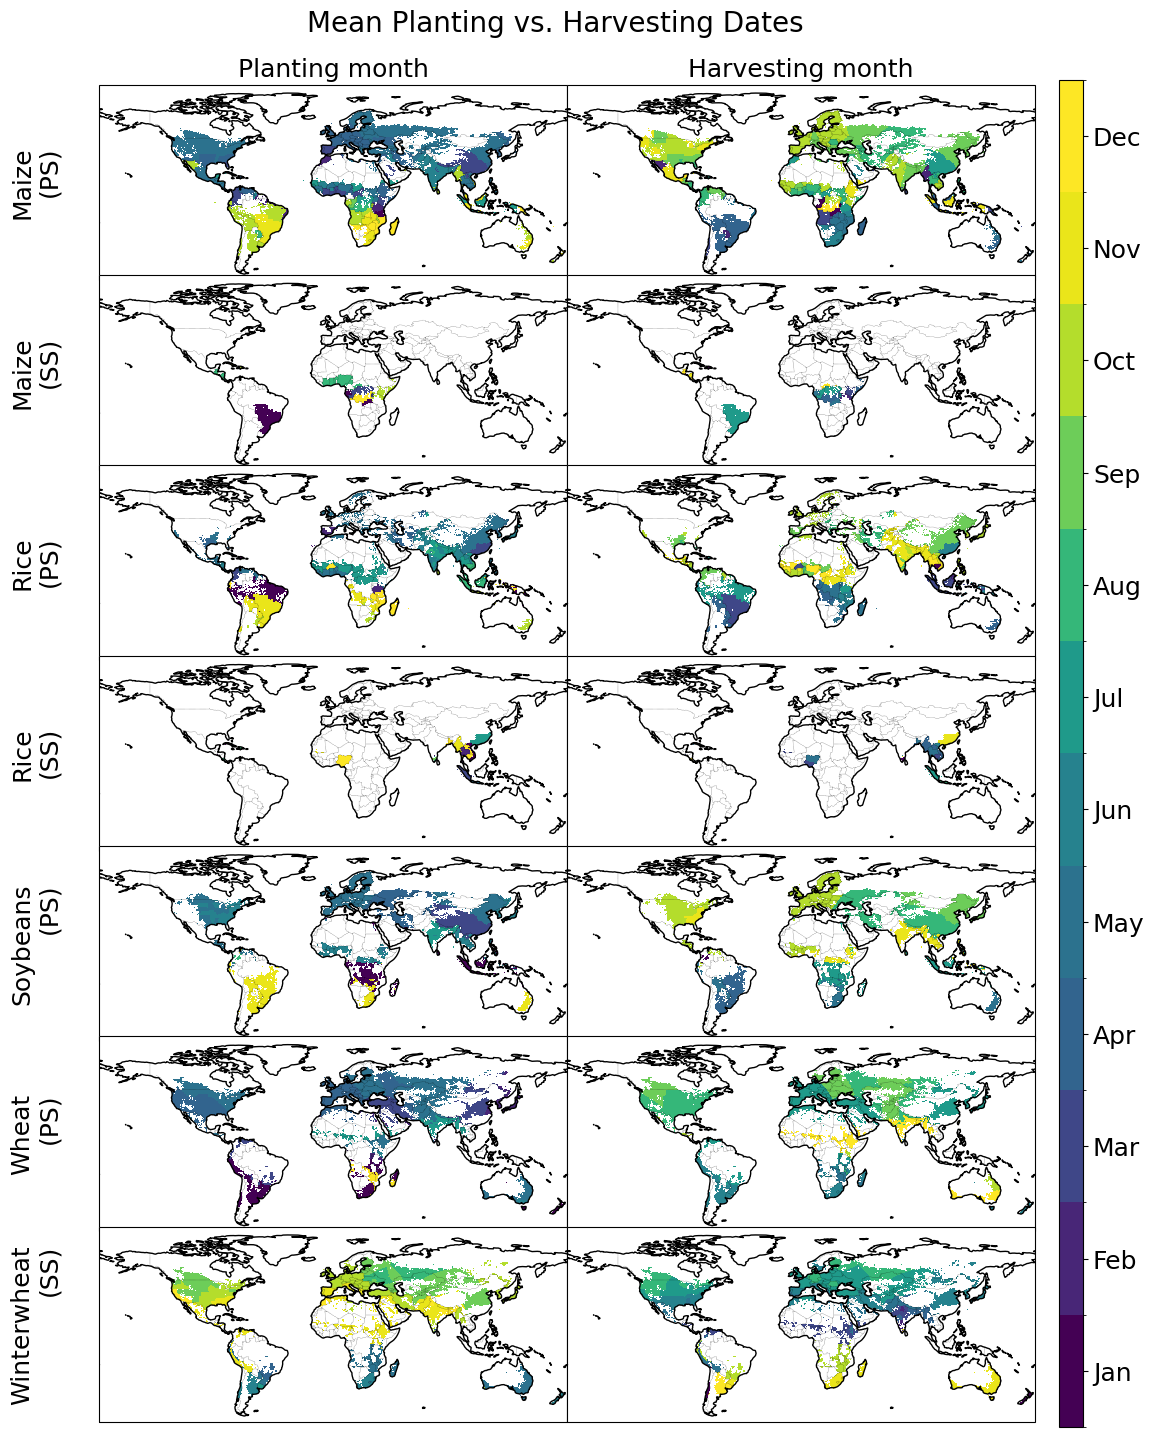

In [18]:
plant_dsets = [
    maize_plant_dates, maize2_plant_dates,
    rice_plant_dates,  rice2_plant_dates,
    soybeans_plant_dates,
    wheat_plant_dates, wheatwinter_plant_dates
]
harv_dsets = [
    maize_harvest_dates, maize2_harvest_dates,
    rice_harvest_dates,  rice2_harvest_dates,
    soybeans_harvest_dates,
    wheat_harvest_dates, wheatwinter_harvest_dates
]
row_labels = [
    "Maize\n(PS)",    "Maize\n(SS)",
    "Rice\n(PS)",     "Rice\n(SS)",
    "Soybeans\n(PS)",
    "Wheat\n(PS)",     "Winterwheat\n(SS)"
]

nrows = len(row_labels)

# convert a 2D string-array "Mon DD" → integer months 1–12
# build mapping January→1 … December→12
month_map = {
    m: i+1 for i,m in enumerate(
        pd.date_range("2000-01-01","2000-12-31",freq="MS").strftime("%B")
    )
}

def to_month_number(da_str):
    """Take an xarray DataArray of shape (lat,lon) with strings 'Mon DD' 
       and return a numpy 2D array of month-indices 1–12 (or nan)."""
    arr = da_str.values
    out = np.full(arr.shape, np.nan)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i,j]
            if isinstance(v, str):
                mon = v.split()[0]
                if mon in month_map:
                    out[i,j] = month_map[mon]
    return out

# 3) set up colormap + norm for 12 discrete months
month_cols = [
    "#440154","#482677","#3F4788","#32648E",
    "#2C728E","#26828E","#1F9A8A","#35B779",
    "#6DCD59","#B4DD2C","#EAE51A","#FDE725"
]
cmap = mcolors.ListedColormap(month_cols)

# bin edges at 0.5,1.5,…,12.5 so that integer months sit centered
bounds = np.arange(0.5, 13.5, 1.0)
norm   = mcolors.BoundaryNorm(bounds, ncolors=cmap.N, clip=True)


fig, axes = plt.subplots(
    nrows, 2,
    figsize=(12,  2.5*nrows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
fig.suptitle("Mean Planting vs. Harvesting Dates", fontsize=20, y=0.91)

# column titles
axes[0,0].set_title("Planting month",   fontsize=18)
axes[0,1].set_title("Harvesting month", fontsize=18)


for i in range(nrows):
    # label the row with the crop/season name
    ax0 = axes[i,0]
    ax0.text(
        -0.08, 0.5, row_labels[i],
        transform=ax0.transAxes,
        va='center', ha='right',
        rotation=90, fontsize=18
    )
    for j, da in enumerate((plant_dsets[i], harv_dsets[i])):
        ax = axes[i,j]
        # convert strings → month number grid
        mnum = to_month_number(da)
        lon = da.longitude.values
        lat = da.latitude.values
        Lon, Lat = np.meshgrid(lon, lat)
        # plot
        im = ax.pcolormesh(
            Lon, Lat, mnum,
            cmap=cmap, norm=norm, shading='auto',
            transform=ccrs.PlateCarree()
        )
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.3)
        ax.set_extent([-182,180,-60,90], ccrs.PlateCarree())

cax = fig.add_axes([0.92, 0.10, 0.02, 0.77])  # [left, bottom, width, height]
cb = fig.colorbar(
    im, cax=cax, orientation='vertical',
    boundaries=bounds, ticks=np.arange(1,13),
    spacing='proportional', extend='neither', shrink=0.5
)
cb.ax.set_yticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)
# cb.set_label("Month of year", fontsize=12)
cb.ax.tick_params(labelsize=18)

# tighten up
fig.subplots_adjust(
    left=0.12, right=0.90,
    top=0.92, bottom=0.05,
    hspace=-0.5, wspace=0.0
)

plt.show()

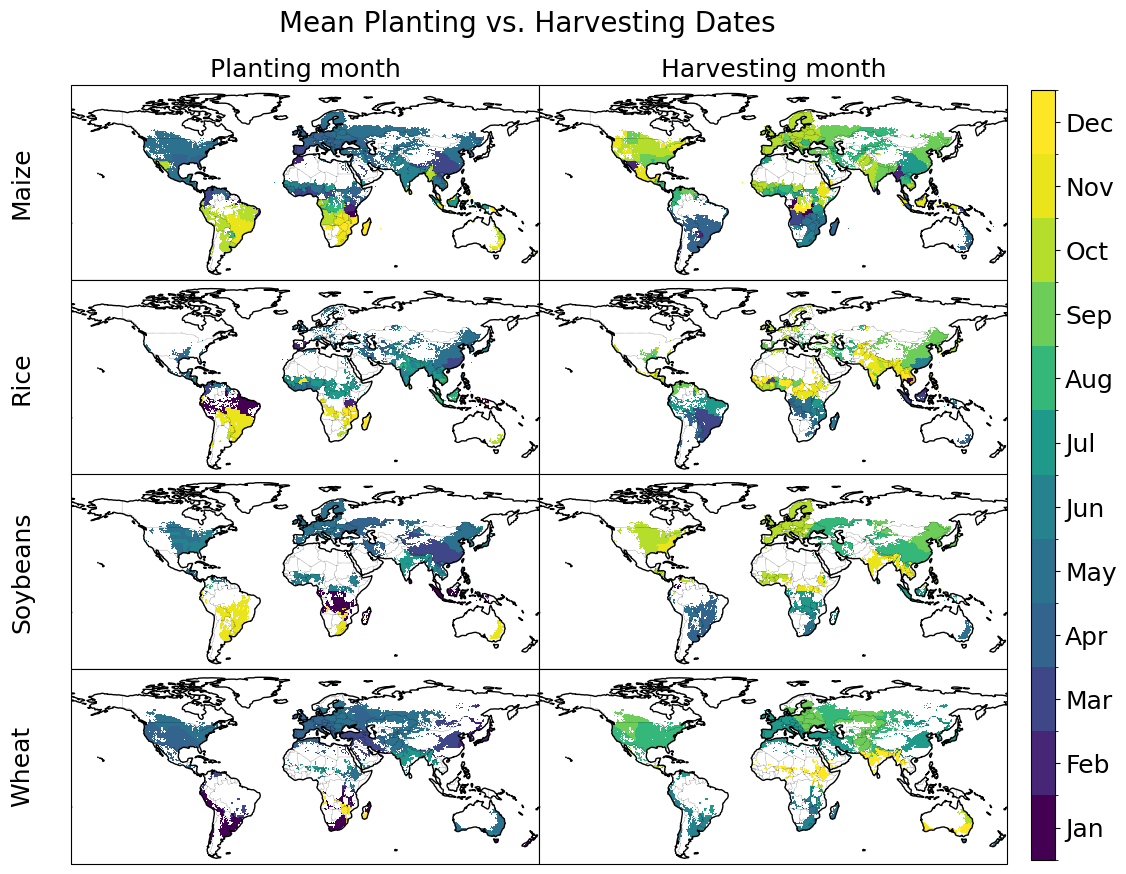

In [31]:
plant_dsets = [
    maize_plant_dates,
    rice_plant_dates,
    soybeans_plant_dates,
    wheat_plant_dates
]

harv_dsets = [
    maize_harvest_dates,
    rice_harvest_dates,
    soybeans_harvest_dates,
    wheat_harvest_dates
]

row_labels = [
    "Maize",
    "Rice",
    "Soybeans",
    "Wheat"
]

nrows = len(row_labels)

# convert a 2D string-array "Mon DD" → integer months 1–12
# build mapping January→1 … December→12
month_map = {
    m: i+1 for i,m in enumerate(
        pd.date_range("2000-01-01","2000-12-31",freq="MS").strftime("%B")
    )
}

def to_month_number(da_str):
    """Take an xarray DataArray of shape (lat,lon) with strings 'Mon DD' 
       and return a numpy 2D array of month-indices 1–12 (or nan)."""
    arr = da_str.values
    out = np.full(arr.shape, np.nan)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i,j]
            if isinstance(v, str):
                mon = v.split()[0]
                if mon in month_map:
                    out[i,j] = month_map[mon]
    return out

# 3) set up colormap + norm for 12 discrete months
month_cols = [
    "#440154","#482677","#3F4788","#32648E",
    "#2C728E","#26828E","#1F9A8A","#35B779",
    "#6DCD59","#B4DD2C","#EAE51A","#FDE725"
]
cmap = mcolors.ListedColormap(month_cols)

# bin edges at 0.5,1.5,…,12.5 so that integer months sit centered
bounds = np.arange(0.5, 13.5, 1.0)
norm   = mcolors.BoundaryNorm(bounds, ncolors=cmap.N, clip=True)


fig, axes = plt.subplots(
    nrows, 2,
    figsize=(12,  2.5*nrows),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
fig.suptitle("Mean Planting vs. Harvesting Dates", fontsize=20, y=0.95)

# column titles
axes[0,0].set_title("Planting month",   fontsize=18)
axes[0,1].set_title("Harvesting month", fontsize=18)


for i in range(nrows):
    # label the row with the crop/season name
    ax0 = axes[i,0]
    ax0.text(
        -0.08, 0.5, row_labels[i],
        transform=ax0.transAxes,
        va='center', ha='right',
        rotation=90, fontsize=18
    )
    for j, da in enumerate((plant_dsets[i], harv_dsets[i])):
        ax = axes[i,j]
        # convert strings → month number grid
        mnum = to_month_number(da)
        lon = da.longitude.values
        lat = da.latitude.values
        Lon, Lat = np.meshgrid(lon, lat)
        # plot
        im = ax.pcolormesh(
            Lon, Lat, mnum,
            cmap=cmap, norm=norm, shading='auto',
            transform=ccrs.PlateCarree()
        )
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.3)
        ax.set_extent([-182,180,-60,90], ccrs.PlateCarree())

cax = fig.add_axes([0.92, 0.10, 0.02, 0.77])  # [left, bottom, width, height]
cb = fig.colorbar(
    im, cax=cax, orientation='vertical',
    boundaries=bounds, ticks=np.arange(1,13),
    spacing='proportional', extend='neither', shrink=0.5
)
cb.ax.set_yticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"]
)
# cb.set_label("Month of year", fontsize=12)
cb.ax.tick_params(labelsize=18)

# tighten up
fig.subplots_adjust(
    left=0.12, right=0.90,
    top=0.92, bottom=0.05,
    hspace=-0.32, wspace=0.0
)

plt.show()

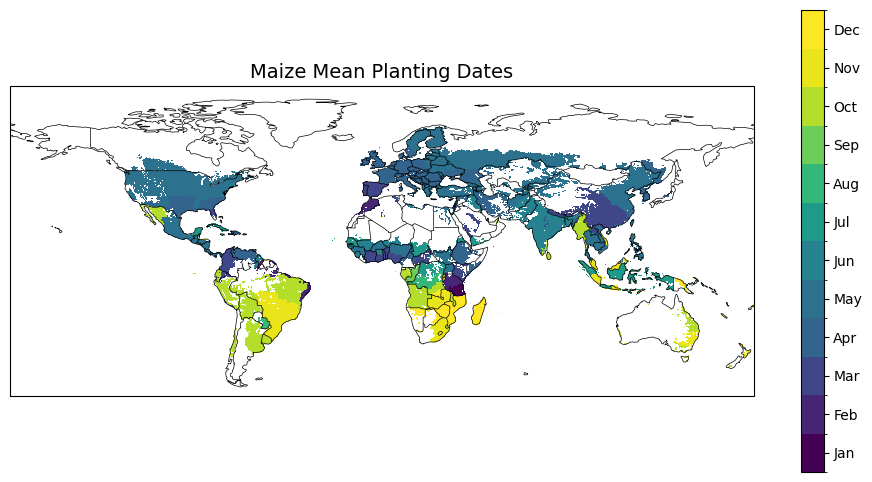

In [19]:
# Extract lat, lon, and plant dates
lat = maize_plant_dates.latitude.values
lon = maize_plant_dates.longitude.values
plant_dates = maize_plant_dates.values  # Contains "Month Day" strings

# Create a meshgrid of lat/lon (for proper spatial alignment)
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Define a dictionary to convert month names to numbers (1-12)
month_mapping = {
    month: i + 1 for i, month in enumerate(
        pd.date_range("2000-01-01", "2000-12-31", freq="MS").strftime("%B")
    )
}

# Initialize a numerical array (same shape as plant_dates)
plant_dates_numeric = np.full(plant_dates.shape, np.nan)

# Convert "Month Day" strings to month indices (1-12)
for i in range(plant_dates.shape[0]):
    for j in range(plant_dates.shape[1]):
        value = plant_dates[i, j]
        if isinstance(value, str):  # Ensure it's a valid string
            month_str = value.split()[0]  # Extract only the month
            if month_str in month_mapping:
                plant_dates_numeric[i, j] = month_mapping[month_str]  # Convert to 1-12
                
month_colors = [
    "#440154", "#482677", "#3F4788", "#32648E", "#2C728E", "#26828E",
    "#1F9A8A", "#35B779", "#6DCD59", "#B4DD2C", "#EAE51A", "#FDE725"
]
cmap = mcolors.ListedColormap(month_colors)

# *** define discrete boundaries & normalization ***
bounds = np.arange(0.5, 13.5, 1)                    # [0.5,1.5,…,12.5]
norm   = mcolors.BoundaryNorm(bounds, ncolors=cmap.N)

fig, ax = plt.subplots(
    1, 1, figsize=(12,6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
ax.set_extent([-182,180,-60,90], ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_grid, lat_grid, plant_dates_numeric,
    cmap=cmap, norm=norm, shading='auto',
    transform=ccrs.PlateCarree()
)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_title("Maize Mean Planting Dates", fontsize=14)

# now the colorbar uses our boundaries
cbar = plt.colorbar(
    im, ax=ax, orientation='vertical',
    boundaries=bounds,            # align bins
    ticks=np.arange(1,13),        # one tick at each integer
    spacing='proportional'        # ensure equal bin widths
)
cbar.ax.set_yticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.show() # make the maps for the rest of the crops in this manner

In [25]:
# # Define crop names
# crop_calendar_names = ["maize", "maize2", "rice", "rice2", "soybeans", "wheat", "wheatwinter"]
# crop_area_names = ["maize", "rice", "soybean", "wheat"]  # Only these crops have crop area data

# # Load crop calendar datasets
# datasets = {
#     "maize": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.crop.calendar.fill.nc'),
#     "maize2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.2.crop.calendar.fill.nc'),
#     "rice": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.crop.calendar.fill.nc'),
#     "rice2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.2.crop.calendar.fill.nc'),
#     "soybeans": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Soybeans.crop.calendar.fill.nc'),
#     "wheat": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.crop.calendar.fill.nc'),
#     "wheatwinter": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.Winter.crop.calendar.fill.nc'),
# }

# # Load crop area datasets (only for the 4 available crops)
# crop_areas = {
#     "maize": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_maize.nc")["croparea"],
#     "maize2": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_maize.nc")["croparea"],
#     "rice": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_rice.nc")["croparea"],
#     "rice2": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_rice.nc")["croparea"],
#     "soybeans": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_soybean.nc")["croparea"],
#     "wheat": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_wheat.nc")["croparea"],
#     "wheatwinter": xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_wheat.nc")["croparea"],
# }

# # Mask crop area data to remove non-crop regions
# masked_crop_areas = {crop: data.where(data > 0) for crop, data in crop_areas.items()}

# # Function to mask planting or harvest dates using high-resolution crop area
# def mask_dates(plant_or_harvest_dates, crop_area):
#     # Get lat/lon values
#     lat_coarse = plant_or_harvest_dates.latitude.values
#     lon_coarse = plant_or_harvest_dates.longitude.values

#     # Copy the dataset
#     masked_dates = plant_or_harvest_dates.copy()

#     # Define half-resolution step for coarse grid
#     coarse_res = 0.5  
#     half_res = coarse_res / 2

#     # Optimize the loop using vectorized xarray selection
#     for i, lat in enumerate(lat_coarse):
#         for j, lon in enumerate(lon_coarse):
#             # Define bounding box for the high-res grid within this coarse grid cell
#             lat_min, lat_max = lat - half_res, lat + half_res
#             lon_min, lon_max = lon - half_res, lon + half_res

#             # Select high-res crop area pixels within this coarse grid cell
#             fine_crop_area = crop_area.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

#             # If all values within this coarse grid cell are NaN, mask plant date
#             if fine_crop_area.isnull().all():
#                 masked_dates[i, j] = np.nan

#     return masked_dates

# # Dictionary to store masked planting and harvest dates
# masked_plant_dates_all = {}
# masked_harvest_dates_all = {}

# # Process each crop
# for crop in crop_calendar_names:
#     print(f"Processing {crop}...")

#     # Extract plant and harvest dates
#     plant_dates = datasets[crop]['plant']
#     harvest_dates = datasets[crop]['harvest']

#     # If crop has crop area data, use masking; otherwise, keep original
#     if crop in masked_crop_areas:
#         print(f"Applying crop mask for {crop}...")
#         masked_plant_dates_all[crop] = mask_dates(plant_dates, masked_crop_areas[crop])
#         masked_harvest_dates_all[crop] = mask_dates(harvest_dates, masked_crop_areas[crop])
#     else:
#         print(f"No crop area available for {crop}, keeping unmasked data.")
#         masked_plant_dates_all[crop] = plant_dates
#         masked_harvest_dates_all[crop] = harvest_dates

# # Display summaries
# masked_plant_dates_all, masked_harvest_dates_all

Processing maize...
Applying crop mask for maize...
Processing maize2...
Applying crop mask for maize2...
Processing rice...
Applying crop mask for rice...
Processing rice2...
Applying crop mask for rice2...
Processing soybeans...
Applying crop mask for soybeans...
Processing wheat...
Applying crop mask for wheat...
Processing wheatwinter...
Applying crop mask for wheatwinter...


({'maize': <xarray.DataArray 'plant' (latitude: 360, longitude: 720)>
  [259200 values with dtype=float32]
  Coordinates:
    * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
    * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  Attributes:
      units:      day of year
      long_name:  Maize: Planting date,
  'maize2': <xarray.DataArray 'plant' (latitude: 360, longitude: 720)>
  [259200 values with dtype=float32]
  Coordinates:
    * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
    * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
  Attributes:
      units:      day of year
      long_name:  Maize.2: Planting date,
  'rice': <xarray.DataArray 'plant' (latitude: 360, longitude: 720)>
  [259200 values with dtype=float32]
  Coordinates:
    * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
    * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -

In [26]:
# # Save masked planting dates as NetCDF files
# for crop, data in masked_plant_dates_all.items():
#     filename = f"/home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_{crop}.nc"
#     data.to_netcdf(filename)
#     print(f"Saved: {filename}")

# # Save masked harvest dates as NetCDF files
# for crop, data in masked_harvest_dates_all.items():
#     filename = f"/home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_harvest_dates_{crop}.nc"
#     data.to_netcdf(filename)
#     print(f"Saved: {filename}")

# # Verify saved files
# import os
# saved_files = [f for f in os.listdir() if f.startswith("masked_plant_dates_") or f.startswith("masked_harvest_dates_")]
# print("Saved NetCDF files:", saved_files)

Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_maize.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_maize2.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_rice.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_rice2.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_soybeans.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_wheat.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_plant_dates_wheatwinter.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_harvest_dates_maize.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_harvest_dates_maize2.nc
Saved: /home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/masked_harvest_dates_rice.nc
Saved: /home/madhulika.gurazada/paper2/Data/C

In [41]:
# the below code can be run independently

In [157]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

In [158]:
crops_primary = ["maize", "maize2", "rice", "rice2", "soybeans", "wheat", "wheatwinter"]
base_path = "/home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly"

masked_plant_dates_all = {
    crop: xr.open_dataarray(f"{base_path}/masked_plant_dates_{crop}.nc")
    for crop in crops_primary
}
masked_harvest_dates_all = {
    crop: xr.open_dataarray(f"{base_path}/masked_harvest_dates_{crop}.nc")
    for crop in crops_primary
}

In [159]:
masked_plant_dates_all['maize']

<xarray.DataArray 'plant' (latitude: 360, longitude: 720)>
[259200 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
Attributes:
    units:      day of year
    long_name:  Maize: Planting date

In [160]:
masked_harvest_dates_all['maize']

<xarray.DataArray 'harvest' (latitude: 360, longitude: 720)>
[259200 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
Attributes:
    units:      day of year
    long_name:  Maize: Harvest date

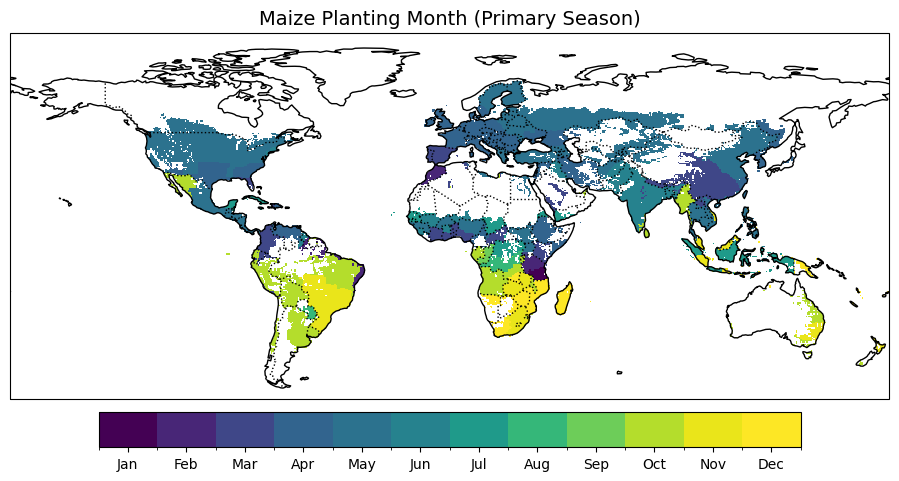

In [161]:
# 1. Get the masked day-of-year data
da = masked_plant_dates_all["maize"]

# 2. Convert day-of-year to month using pandas
def doy_to_month(doy_array):
    """Convert numeric day-of-year to month number (1–12), keeping NaNs."""
    flat = doy_array.flatten()
    months = []
    for v in flat:
        if np.isnan(v):
            months.append(np.nan)
        else:
            date = pd.to_datetime(f"2001-01-01") + pd.to_timedelta(int(v) - 1, unit='D')
            months.append(date.month)
    return np.array(months).reshape(doy_array.shape)

# Apply conversion
month_vals = doy_to_month(da.values)

# 3. Define colormap
month_cols = [
    "#440154","#482677","#3F4788","#32648E",
    "#2C728E","#26828E","#1F9A8A","#35B779",
    "#6DCD59","#B4DD2C","#EAE51A","#FDE725"
]
cmap = mcolors.ListedColormap(month_cols)
bounds = np.arange(0.5, 13.5, 1)
norm = mcolors.BoundaryNorm(bounds, ncolors=cmap.N)

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})
lon, lat = da.longitude.values, da.latitude.values
Lon, Lat = np.meshgrid(lon, lat)

im = ax.pcolormesh(Lon, Lat, month_vals, cmap=cmap, norm=norm, shading='auto')
ax.set_extent([-182,180,-60,90], ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title("Maize Planting Month (Primary Season)", fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.03, boundaries=bounds, ticks=np.arange(1, 13), shrink=0.6)
cbar.ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

plt.tight_layout()
plt.show()


In [162]:
def doy_to_month_array(doy_array):
    """Convert day-of-year values (float32) to month numbers (1–12), preserving NaNs."""
    flat = doy_array.flatten()
    months = []
    for v in flat:
        if np.isnan(v):
            months.append(np.nan)
        else:
            date = pd.to_datetime("2001-01-01") + pd.to_timedelta(int(v) - 1, unit='D')
            months.append(date.month)
    return np.array(months).reshape(doy_array.shape)

In [66]:
# # Planting
# maize_plant_doy = masked_plant_dates_all["maize"].values
# maize_plant_month = doy_to_month_array(maize_plant_doy)

# # Harvesting
# maize_harvest_doy = masked_harvest_dates_all["maize"].values
# maize_harvest_month = doy_to_month_array(maize_harvest_doy)

In [163]:
plant_month_all = {}
harvest_month_all = {}

for crop in crops_primary:
    print(f"Processing: {crop}")
    
    # Extract DOY values
    plant_doy = masked_plant_dates_all[crop].values
    harvest_doy = masked_harvest_dates_all[crop].values

    # Convert to month
    plant_month_all[crop] = doy_to_month_array(plant_doy)
    harvest_month_all[crop] = doy_to_month_array(harvest_doy)


Processing: maize
Processing: maize2
Processing: rice
Processing: rice2
Processing: soybeans
Processing: wheat
Processing: wheatwinter


In [164]:
month_to_season = {
    12: 'djf', 1: 'djf', 2: 'djf',
    3: 'mam', 4: 'mam', 5: 'mam',
    6: 'jja', 7: 'jja', 8: 'jja',
    9: 'son', 10: 'son', 11: 'son'
}
season_to_id = {'djf': 1, 'mam': 2, 'jja': 4, 'son': 8}

In [165]:
def growing_months(p, h):
    if np.isnan(p) or np.isnan(h):
        return []
    p = int(p)
    h = int(h)
    if h >= p:
        return list(range(p, h + 1))
    else:
        return list(range(p, 13)) + list(range(1, h + 1))


In [74]:
# season_count_map = np.full(maize_plant_month.shape, np.nan)
# season_code_map = np.full(maize_plant_month.shape, np.nan)

# for i in range(maize_plant_month.shape[0]):
#     for j in range(maize_plant_month.shape[1]):
#         p = maize_plant_month[i, j]
#         h = maize_harvest_month[i, j]
#         months = growing_months(p, h)
#         seasons = set(month_to_season[m] for m in months if m in month_to_season)
#         season_count_map[i, j] = len(seasons)
#         season_code_map[i, j] = sum(season_to_id[s] for s in seasons)


In [166]:
season_count_all = {}
season_code_all = {}

for crop in crops_primary:
    print(f"Computing growing seasons for: {crop}")
    
    # Get planting and harvesting month arrays
    plant_month = plant_month_all[crop]
    harvest_month = harvest_month_all[crop]

    # Initialize output arrays
    season_count = np.full(plant_month.shape, np.nan)
    season_code = np.full(plant_month.shape, np.nan)

    # Loop over each grid cell
    for i in range(plant_month.shape[0]):
        for j in range(plant_month.shape[1]):
            p = plant_month[i, j]
            h = harvest_month[i, j]
            months = growing_months(p, h)

            # Determine seasons spanned by the growing window
            seasons = set(month_to_season[m] for m in months if m in month_to_season)
            season_ids = [season_to_id[s] for s in seasons]

            # Store outputs
            season_count[i, j] = len(season_ids)
            season_code[i, j] = sum(season_ids)

    # Store each crop's results in dictionaries
    season_count_all[crop] = season_count
    season_code_all[crop] = season_code

Computing growing seasons for: maize
Computing growing seasons for: maize2
Computing growing seasons for: rice
Computing growing seasons for: rice2
Computing growing seasons for: soybeans
Computing growing seasons for: wheat
Computing growing seasons for: wheatwinter


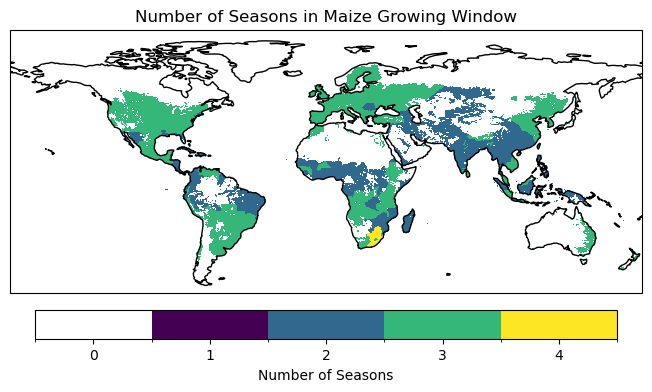

In [83]:
# # Define boundaries and ticks
# bounds = [0, 1, 2, 3, 4, 5]
# ticks = [0.5, 1.5, 2.5, 3.5, 4.5]
# labels = ['0', '1', '2', '3', '4']

# # Custom colormap: white for 0, viridis for 1–4
# viridis = plt.get_cmap('viridis', 4)  # 4 bins for 1–4
# colors = ['#ffffff'] + [viridis(i) for i in range(4)]
# cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(bounds, len(colors))

# # Plot
# plt.figure(figsize=(10, 4))
# ax = plt.axes(projection=ccrs.PlateCarree())
# plt.title("Number of Seasons in Maize Growing Window")
# im = ax.pcolormesh(Lon, Lat, season_count_map, cmap=cmap, norm=norm, shading='auto')
# ax.coastlines()
# ax.set_extent([-182, 180, -60, 90], ccrs.PlateCarree())

# # Discrete colorbar
# cbar = plt.colorbar(im, orientation='horizontal', pad=0.05, boundaries=bounds, ticks=ticks, shrink=0.6)
# cbar.ax.set_xticklabels(labels)
# cbar.set_label("Number of Seasons")

# plt.tight_layout()
# plt.show()


/tmp/ipykernel_4008905/2332486456.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


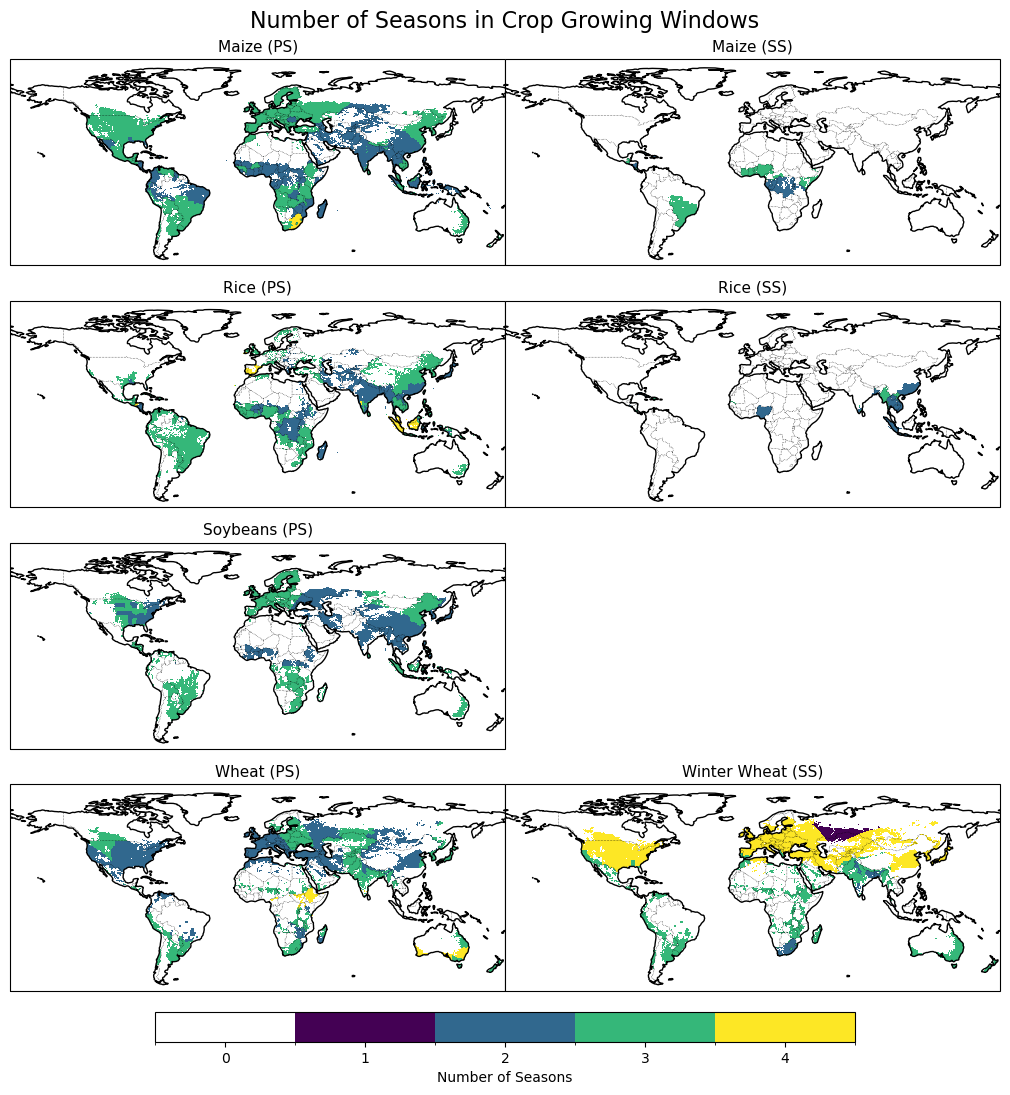

In [167]:
# Discrete color settings
bounds = [0, 1, 2, 3, 4, 5]
ticks = [0.5, 1.5, 2.5, 3.5, 4.5]
labels = ['0', '1', '2', '3', '4']
viridis = plt.get_cmap('viridis', 4)
colors = ['#ffffff'] + [viridis(i) for i in range(4)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, len(colors))

# Grid layout: 4 rows × max 2 columns
panel_order = [
    ["maize", "maize2"],
    ["rice", "rice2"],
    ["soybeans", None],
    ["wheat", "wheatwinter"]
]

# Title mapping
crop_title_map = {
    "maize": "Maize (PS)",
    "maize2": "Maize (SS)",
    "rice": "Rice (PS)",
    "rice2": "Rice (SS)",
    "soybeans": "Soybeans (PS)",
    "wheat": "Wheat (PS)",
    "wheatwinter": "Winter Wheat (SS)"
}

# Coordinates
lat = masked_plant_dates_all["maize"].latitude.values
lon = masked_plant_dates_all["maize"].longitude.values
Lon, Lat = np.meshgrid(lon, lat)

# Set up figure and axes
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-4.9, wspace=-0.2)  # Adjust spacing

# Plot each subplot
for row_idx, row in enumerate(panel_order):
    for col_idx, crop in enumerate(row):
        ax = axes[row_idx, col_idx]

        if crop is None:
            ax.axis("off")
            continue

        season_count_map = season_count_all[crop]
        title = crop_title_map.get(crop, crop.capitalize())

        im = ax.pcolormesh(Lon, Lat, season_count_map, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(title, fontsize=11)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())

# Shared colorbar (bottom)
cax = fig.add_axes([0.25, 0.07, 0.5, 0.025])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', boundaries=bounds, ticks=ticks)
cbar.ax.set_xticklabels(labels)
cbar.set_label("Number of Seasons")

plt.suptitle("Number of Seasons in Crop Growing Windows", fontsize=16, y=0.93)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

/tmp/ipykernel_4008905/1708398442.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


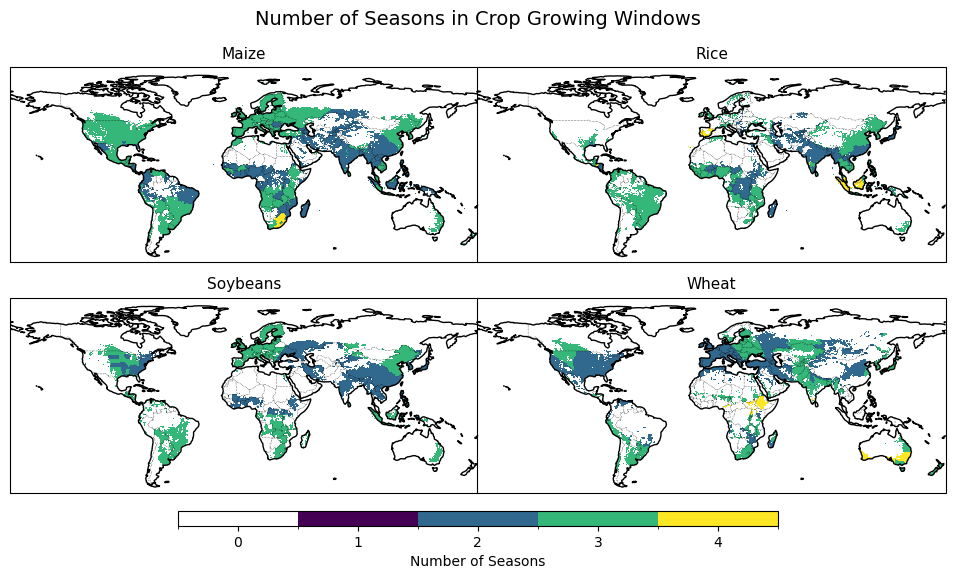

In [175]:
# Discrete color settings
bounds = [0, 1, 2, 3, 4, 5]
ticks = [0.5, 1.5, 2.5, 3.5, 4.5]
labels = ['0', '1', '2', '3', '4']
viridis = plt.get_cmap('viridis', 4)
colors = ['#ffffff'] + [viridis(i) for i in range(4)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, len(colors))

# Panel layout: 2 rows × 2 columns for primary season crops
panel_order = [
    ["maize", "rice"],
    ["soybeans", "wheat"]
]

crop_title_map = {
    "maize": "Maize",
    "rice": "Rice",
    "soybeans": "Soybeans",
    "wheat": "Wheat"
}

# Coordinates
lat = masked_plant_dates_all["maize"].latitude.values
lon = masked_plant_dates_all["maize"].longitude.values
Lon, Lat = np.meshgrid(lon, lat)

# Set up figure and axes
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.3, wspace=-0.73)

# Plot each subplot
for row_idx, row in enumerate(panel_order):
    for col_idx, crop in enumerate(row):
        ax = axes[row_idx, col_idx]
        season_count_map = season_count_all[crop]
        title = crop_title_map[crop]

        im = ax.pcolormesh(Lon, Lat, season_count_map, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(title, fontsize=11)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())

# Shared colorbar
cax = fig.add_axes([0.25, 0.07, 0.5, 0.025])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', boundaries=bounds, ticks=ticks)
cbar.ax.set_xticklabels(labels)
cbar.set_label("Number of Seasons")

plt.suptitle("Number of Seasons in Crop Growing Windows", fontsize=14, y=0.93)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

/tmp/ipykernel_4008905/2124662530.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


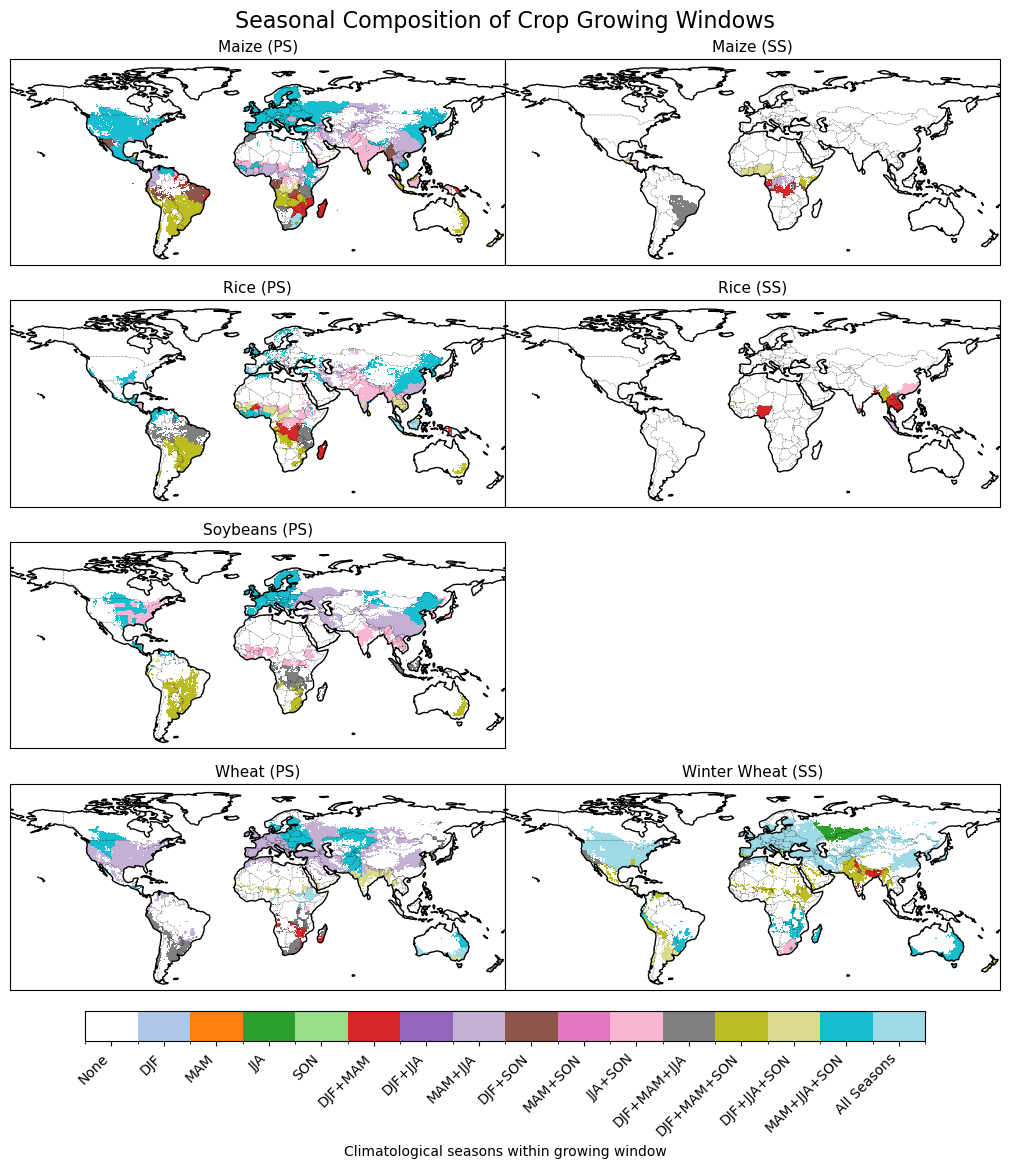

In [176]:
# Custom display order (None, singles, doublets, triplets, all)
ordered_code_label = [
    (0, "None"),
    (1, "DJF"),
    (2, "MAM"),
    (4, "JJA"),
    (8, "SON"),
    (3, "DJF+MAM"),
    (5, "DJF+JJA"),
    (6, "MAM+JJA"),
    (9, "DJF+SON"),
    (10, "MAM+SON"),
    (12, "JJA+SON"),
    (7, "DJF+MAM+JJA"),
    (11, "DJF+MAM+SON"),
    (13, "DJF+JJA+SON"),
    (14, "MAM+JJA+SON"),
    (15, "All Seasons")
]

ordered_labels = [label for _, label in ordered_code_label]
ordered_codes_display = [code for code, _ in ordered_code_label]

code_to_index = {code: idx for idx, code in enumerate(ordered_codes_display)}
monotonic_codes = list(range(len(ordered_codes_display)))

colors = plt.cm.tab20(np.linspace(0, 1, len(monotonic_codes)))
colors[code_to_index[0]] = [1, 1, 1, 1]
cmap = mcolors.ListedColormap(colors)
bounds = list(range(len(monotonic_codes) + 1))
norm = mcolors.BoundaryNorm(bounds, len(bounds) - 1)

panel_order = [
    ["maize", "maize2"],
    ["rice", "rice2"],
    ["soybeans", None],
    ["wheat", "wheatwinter"]
]

lat = masked_plant_dates_all["maize"].latitude.values
lon = masked_plant_dates_all["maize"].longitude.values
Lon, Lat = np.meshgrid(lon, lat)

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=-4.9, wspace=-0.2)

for row_idx, row in enumerate(panel_order):
    for col_idx, crop in enumerate(row):
        ax = axes[row_idx, col_idx]
        if crop is None:
            ax.axis("off")
            continue

        season_map = season_code_all[crop]
        remapped = np.full(season_map.shape, np.nan)
        for code, idx in code_to_index.items():
            remapped[season_map == code] = idx

        # Custom titles
        if crop == "maize":
            title = "Maize (PS)"
        elif crop == "maize2":
            title = "Maize (SS)"
        elif crop == "rice":
            title = "Rice (PS)"
        elif crop == "rice2":
            title = "Rice (SS)"
        elif crop == "soybeans":
            title = "Soybeans (PS)"
        elif crop == "wheat":
            title = "Wheat (PS)"
        elif crop == "wheatwinter":
            title = "Winter Wheat (SS)"
        else:
            title = crop.capitalize()

        im = ax.pcolormesh(Lon, Lat, remapped, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(title, fontsize=11)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.2, 0.07, 0.6, 0.025])
tick_locs = [i + 0.5 for i in monotonic_codes]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', boundaries=bounds, ticks=tick_locs)
cbar.ax.set_xticklabels(ordered_labels, rotation=45, ha='right')
cbar.set_label("Climatological seasons within growing window")

plt.suptitle("Seasonal Composition of Crop Growing Windows", fontsize=16, y=0.93)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

/tmp/ipykernel_4008905/235229747.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


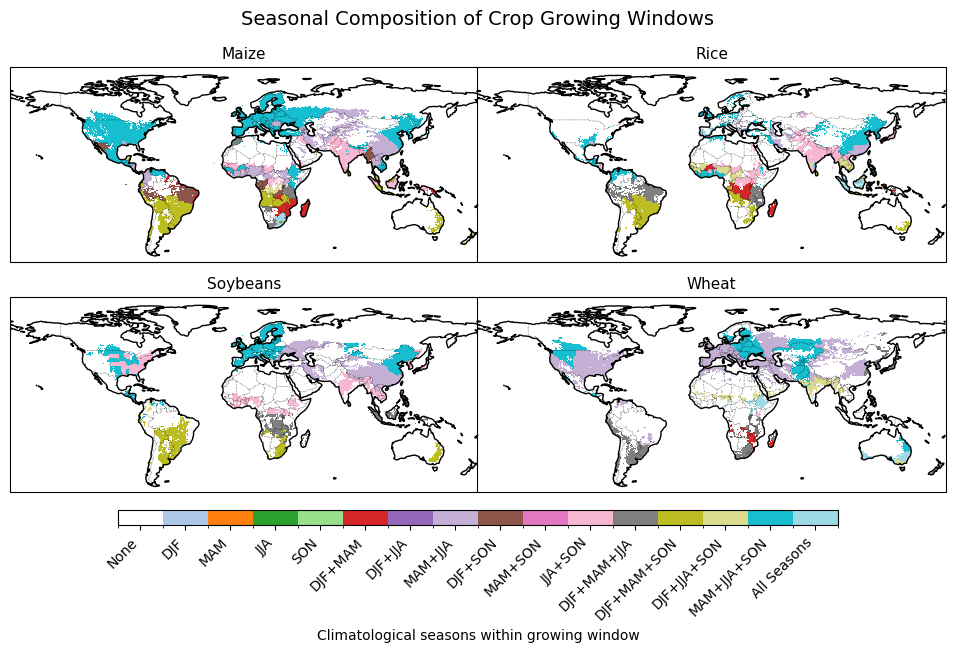

In [179]:
# Custom display order (None, singles, doublets, triplets, all)
ordered_code_label = [
    (0, "None"),
    (1, "DJF"),
    (2, "MAM"),
    (4, "JJA"),
    (8, "SON"),
    (3, "DJF+MAM"),
    (5, "DJF+JJA"),
    (6, "MAM+JJA"),
    (9, "DJF+SON"),
    (10, "MAM+SON"),
    (12, "JJA+SON"),
    (7, "DJF+MAM+JJA"),
    (11, "DJF+MAM+SON"),
    (13, "DJF+JJA+SON"),
    (14, "MAM+JJA+SON"),
    (15, "All Seasons")
]

ordered_labels = [label for _, label in ordered_code_label]
ordered_codes_display = [code for code, _ in ordered_code_label]
code_to_index = {code: idx for idx, code in enumerate(ordered_codes_display)}
monotonic_codes = list(range(len(ordered_codes_display)))

colors = plt.cm.tab20(np.linspace(0, 1, len(monotonic_codes)))
colors[code_to_index[0]] = [1, 1, 1, 1]  # Make 'None' white
cmap = mcolors.ListedColormap(colors)
bounds = list(range(len(monotonic_codes) + 1))
norm = mcolors.BoundaryNorm(bounds, len(bounds) - 1)

# Panel layout for primary seasons only
panel_order = [
    ["maize", "rice"],
    ["soybeans", "wheat"]
]

# Coordinates
lat = masked_plant_dates_all["maize"].latitude.values
lon = masked_plant_dates_all["maize"].longitude.values
Lon, Lat = np.meshgrid(lon, lat)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.3, wspace=-0.73)

for row_idx, row in enumerate(panel_order):
    for col_idx, crop in enumerate(row):
        ax = axes[row_idx, col_idx]

        season_map = season_code_all[crop]
        remapped = np.full(season_map.shape, np.nan)
        for code, idx in code_to_index.items():
            remapped[season_map == code] = idx

        # Titles
        title_map = {
            "maize": "Maize",
            "rice": "Rice",
            "soybeans": "Soybeans",
            "wheat": "Wheat"
        }
        title = title_map.get(crop, crop.capitalize())

        im = ax.pcolormesh(Lon, Lat, remapped, cmap=cmap, norm=norm, shading='auto')
        ax.set_title(title, fontsize=11)
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())

# Shared colorbar
cax = fig.add_axes([0.2, 0.07, 0.6, 0.025])
tick_locs = [i + 0.5 for i in monotonic_codes]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', boundaries=bounds, ticks=tick_locs)
cbar.ax.set_xticklabels(ordered_labels, rotation=45, ha='right')
cbar.set_label("Climatological seasons within growing window")

plt.suptitle("Seasonal Composition of Crop Growing Windows", fontsize=14, y=0.93)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()